# 04 · Lifetime maps

Intensity-modulated maps of the donor phase lifetime: **hue** is
$\tau_\varphi$ of a pixel, **brightness** is the number of photons it was
computed from.

For every image the notebook writes a three-panel figure (intensity,
lifetime map, intensity with the curated masks), and for every construct one
summary figure with all its analysed images on a common scale.

The phasors are calibrated as in notebook 03: one rotation per session from
the rising edge of the decay, and the absolute factor of the donor-only
calibration, read back from `phasors.csv`.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.ndimage import uniform_filter
from skimage import io

from tttrkit.ptuio.reader import TTTRReader
from tttrkit.ptuio.reconstructor import ImageReconstructor

import flim_fret_data_processing.config as config
from flim_fret_data_processing.helpers import (
    MASK_KINDS,
    index_masks,
    index_samples,
    isoluminant_colormap,
    leading_edge_crossing,
    load_sample_rename,
    make_scan_config,
    read_acquisition_params,
    run_reconstruction,
    save_figure,
    scan_shape,
)

plt.rcParams['svg.fonttype'] = 'none'   # keep SVG text editable

## Inputs

In [2]:
# ----------------------------------------------------------------- data in --
root_dir = config.REPO_DIR
raw_dir           = config.RAW_DIR            # <session>/<sample>/*.ptu
mask_dir          = config.MASKS_DIR          # curated masks
sample_rename_csv = config.SAMPLE_NAMES_CSV   # folder name -> construct name
phasor_csv        = os.path.join(config.RESULTS_DIR, "phasors.csv")   # from notebook 03

# ----------------------------------------------------------------- outputs --
# One folder per construct with the per-image figures, plus the summaries.
output_dir = os.path.join(config.RESULTS_DIR, "lifetime_maps")
export_tiffs = True   # also write tau_phi and photon-count maps as float32 TIFF

# ------------------------------------------------------------- acquisition --
target_bin_width_ps    = 40   # TCSPC bin width of the decays used for the timing
frames                 = 5    # z planes per acquisition, summed into one map
fallback_accumulations = 4    # line accumulations when an image has no mask and no .msr
donor_channel          = 1    # detector channel of the donor (mTurquoise2)

# ------------------------------------------------------- session correction --
# One reference sample per session. Its full-field decay, summed over all its
# files, gives the timing offset of the session. Use a bright FRET sample, not
# the donor-only one.
edge_reference_sample = {
    '2025-03-13': '1259',
    '2025-04-09': 'R2F-1',
    '2025-07-30': '12',
    '2025-08-05': '5',
}
edge_fractions = (0.05, 0.10, 0.15, 0.20, 0.25)   # of the peak height

# ------------------------------------------------------------ lifetime map --
spatial_pooling = 3   # side of the square window pixels are pooled over; 1 = off

# One lifetime scale for all maps: the photon-weighted percentiles of the
# pixels with at least `tau_limit_min_photons`, taken over the brightest image
# of each sample in `scale_reference_samples`. Set `tau_limits_ns` to fix it.
tau_limits_ns           = None
tau_percentiles         = (2, 98)
tau_limit_min_photons   = 30
scale_reference_samples = ['1259', '12', '21', '5']

# Isoluminant colourmap: constant CIE L*, hue from blue (short) to red (long).
isoluminant_lightness = 65.0
isoluminant_hue_range = (270, 30)

# Brightness: photon counts stretched between these percentiles of each image,
# then raised to `intensity_gamma`.
intensity_percentiles = (1, 99.5)
intensity_gamma       = 0.7

# ----------------------------------------------------------------- figures --
panel_intensity_percentiles = (1, 99)   # stretch of the greyscale intensity panels
scalebar_um = 2.0

IB_COLOR      = (1.0, 0.2, 0.8)   # magenta
CELL_COLOR    = (0.0, 0.9, 1.0)   # cyan
OVERLAY_ALPHA = 0.45

summary_max_columns = 7     # images per row of a construct summary
summary_panel_size  = 1.4   # width of one summary panel, in inches

## Samples, masks and display names

In [3]:
samples       = index_samples(raw_dir)
masks         = index_masks(mask_dir, samples)
sample_date   = {sample: info['session'] for sample, info in samples.items()}
sample_rename = load_sample_rename(sample_rename_csv)


def display_name(sample):
    """The name `sample` is plotted and exported under."""
    return sample_rename.get(sample, sample)


n_files = sum(len(info['files']) for info in samples.values())
print(f"{len(samples)} sample(s), {n_files} image(s), {len(masks)} mask file(s)")

41 sample(s), 271 image(s), 368 mask file(s)


## Reconstruct every image

One pass per file gives the per-pixel photon counts and phasor sums (z planes
summed) and the accumulated decay of the whole field. Acquisition parameters
come from each file's own header. The pixel grid is that of the curated
masks; images without masks take it from the `.msr` file.

Per-pixel phasor **sums** are kept rather than mean phasors, so that pooling
pixels stays exact: the phasor of a group of pixels is the sum of their
phasor sums over the sum of their counts.

In [4]:
def reconstruct(sample, ptu_file):
    """Per-pixel counts and phasor sums, full-field decay and masks of one image."""
    path = os.path.join(samples[sample]['path'], ptu_file)
    base = os.path.splitext(ptu_file)[0]

    reader = TTTRReader(path)
    tags   = reader.header.tags
    params = read_acquisition_params(tags, target_bin_width_ps)

    image_masks = {kind: io.imread(masks[(sample, base, kind)])
                   for kind in MASK_KINDS if (sample, base, kind) in masks}
    shapes = {mask.shape[:2] for mask in image_masks.values()}
    if len(shapes) > 1:
        raise ValueError(f"IB and cell mask differ in shape: {sorted(shapes)}")
    if shapes:
        lines, pixels = shapes.pop()
    else:
        lines, pixels, _ = scan_shape(path, tags, frames, fallback_accumulations)

    reconstructor = ImageReconstructor(
        config=make_scan_config(tags, lines, pixels, frames),
        omega=2 * np.pi * params['sync_rate'] * params['tcspc_resolution'],
        tcspc_channels=params['tcspc_bins'],
        outputs=['photon_count', 'phasor', 'tcspc_histogram'],
    )
    result = run_reconstruction(reader, reconstructor, params['wrap'])

    counts     = np.asarray(result.photon_count.isel(sequence=0, channel=donor_channel), float)
    counts_all = np.asarray(result.photon_count.isel(sequence=0), float).sum(axis=-1)

    g = np.asarray(result.phasor_g.isel(sequence=0, channel=donor_channel), float)
    s = np.asarray(result.phasor_s.isel(sequence=0, channel=donor_channel), float)
    # phasor_g/s are per-pixel means (NaN where empty); times the count gives sums.
    phasor_sum = np.nan_to_num(g + 1j * s) * counts

    decay = result.tcspc_histogram.coarsen(frame=frames).sum().isel(frame=0, channel=donor_channel)
    decay = decay.coarsen(tcspc_channel=params['tcspc_binning'], boundary='trim').sum()

    return {
        'sample':        sample,
        'ptu_file':      ptu_file,
        'date':          sample_date[sample],
        'counts':        counts.sum(axis=0),       # donor channel
        'counts_all':    counts_all.sum(axis=0),   # both detectors, as exported by notebook 01
        'phasor_sum':    phasor_sum.sum(axis=0),
        'decay':         np.asarray(decay, dtype=np.int64),
        'masks':         image_masks,
        'shape':         (lines, pixels),
        'sync_rate':     params['sync_rate'],
        'bin_width':     params['bin_width'],
        'pixel_size_um': params['pixel_size_um'],
    }


images, failed = {}, []
for sample, info in samples.items():
    for ptu_file in info['files']:
        try:
            images[(sample, ptu_file)] = reconstruct(sample, ptu_file)
        except Exception as error:
            failed.append(f"{sample}/{ptu_file}: {type(error).__name__}: {error}")

print(f"Reconstructed {len(images)} image(s).")
if failed:
    print(f"{len(failed)} image(s) could not be reconstructed:")
    print("\n".join(f"  {line}" for line in failed))

Reconstructed 271 image(s).


## Calibration

**Session rotation.** The timing offset $t_0$ of each session is read from the
rising edge of its reference sample's full-field decay, and the correction is
$c^\text{corr} = e^{-i\omega t_0}$, as in notebook 03.

**Absolute factor.** Every row of `phasors.csv` holds a raw and a calibrated
phasor, so their ratio is the complete factor notebook 03 applied in that
session. Dividing it by the rotation measured here leaves the absolute part,
which is computed for each session separately; the median is used. The
spread between sessions is the disagreement between the two timing estimates.

In [5]:
def reference_decay(sample):
    """(full-field donor decay summed over the sample's files, bin width, sync rate)."""
    entries = [images[(sample, f)] for f in samples[sample]['files']]
    bin_widths = {round(e['bin_width'], 15) for e in entries}
    if len(bin_widths) > 1:
        raise RuntimeError(f"'{sample}' mixes bin widths -- pick another reference sample")

    # Decays binned from 5 ps and recorded at 40 ps differ by one channel in length.
    total = entries[0]['decay']
    for entry in entries[1:]:
        n = min(len(total), len(entry['decay']))
        total = total[:n] + entry['decay'][:n]

    sync_rate = float(np.median(sorted({e['sync_rate'] for e in entries})))
    return total, bin_widths.pop(), sync_rate


correction_factor = {}
edge_rows = []
for date, sample in sorted(edge_reference_sample.items()):
    decay, bin_width, sync_rate = reference_decay(sample)
    t0, spread = leading_edge_crossing(decay, bin_width,
                                       fractions=edge_fractions, return_spread=True)
    # A later pulse means a larger phase, so the correction rotates clockwise.
    omega = 2 * np.pi * sync_rate
    correction_factor[date] = np.exp(-1j * omega * t0)
    edge_rows.append({'date': date, 'sample': sample, 'photons': int(decay.sum()),
                      't0_ps': t0 * 1e12, 'spread_ps': spread * 1e12})

edge_days = pd.DataFrame(edge_rows)

reference = pd.read_csv(phasor_csv)
reference['total'] = ((reference['g'] + 1j * reference['s'])
                      / (reference['g_raw'] + 1j * reference['s_raw']))
absolute = {date: group['total'].dropna().mean() / correction_factor[date]
            for date, group in reference.groupby('date')}

edge_days['modulation']   = [abs(absolute[d]) for d in edge_days['date']]
edge_days['rotation_deg'] = [np.degrees(np.angle(absolute[d])) for d in edge_days['date']]

# Median of the polar parts over the sessions.
absolute_factor = (np.median(edge_days['modulation'])
                   * np.exp(1j * np.radians(np.median(edge_days['rotation_deg']))))
total_factor = {date: factor * absolute_factor for date, factor in correction_factor.items()}

print("Session timing and the absolute factor recovered from each session:\n")
print(edge_days.round(3).to_string(index=False))
print(f"\nabsolute factor: {absolute_factor:.6g}  "
      f"(spread between sessions: {np.ptp(edge_days['rotation_deg']):.3f} deg)")

Session timing and the absolute factor recovered from each session:

      date sample  photons    t0_ps  spread_ps  modulation  rotation_deg
2025-03-13   1259  1994353 1565.254     61.360         1.1        -5.789
2025-04-09  R2F-1  2667128 1538.034     57.556         1.1        -5.850
2025-07-30     12   701125 1455.621     57.458         1.1        -5.857
2025-08-05      5   621417 1435.713     56.220         1.1        -5.827

absolute factor: 1.09443-0.111917j  (spread between sessions: 0.068 deg)


## Lifetime maps

1. **Calibrate** the per-pixel phasor sums with the session factor.
2. **Pool** phasor sums and photon counts over a `spatial_pooling`-wide
   square window, to reduce shot noise.
3. **Phase lifetime**: $\tau_\varphi = s / (\omega g)$.

In [6]:
def lifetime_map(entry):
    """(tau_phi in ns, pooled photon count) of one reconstructed image."""
    phasor_sum = entry['phasor_sum'] * total_factor[entry['date']]
    counts     = entry['counts']

    if spatial_pooling > 1:
        # uniform_filter is a mean; times the window size gives the pooled sums.
        window = spatial_pooling ** 2
        counts = uniform_filter(counts, spatial_pooling, mode='nearest') * window
        phasor_sum = (uniform_filter(phasor_sum.real, spatial_pooling, mode='nearest')
                      + 1j * uniform_filter(phasor_sum.imag, spatial_pooling, mode='nearest')) * window

    omega = 2 * np.pi * entry['sync_rate']
    with np.errstate(divide='ignore', invalid='ignore'):
        phasor = np.where(counts > 0, phasor_sum / np.where(counts > 0, counts, 1), np.nan)
        tau = (phasor.imag / phasor.real) / omega * 1e9

    # g <= 0 is outside the physical half-plane.
    return np.where(phasor.real > 0, tau, np.nan), counts


for entry in images.values():
    entry['tau'], entry['weight'] = lifetime_map(entry)

## Colour scale

All maps share one lifetime scale. The colourmap is isoluminant (constant
CIE L\*), so that hue does not change the perceived brightness and the two
quantities can be read independently.

In [7]:
def weighted_percentile(values, weights, percentiles):
    """Percentiles of `values`, each weighted by its photon count."""
    order = np.argsort(values)
    values, weights = np.asarray(values)[order], np.asarray(weights, float)[order]
    cumulative = np.cumsum(weights) / weights.sum()
    return np.interp(np.asarray(percentiles) / 100.0, cumulative, values)


def usable_pixels(entry):
    """(lifetimes, photon counts) of the pixels with enough photons."""
    good = np.isfinite(entry['tau']) & (entry['weight'] >= tau_limit_min_photons)
    return entry['tau'][good], entry['weight'][good]


def brightest_image(sample):
    """The image of `sample` with the most donor photons."""
    return max((images[(sample, f)] for f in samples[sample]['files'] if (sample, f) in images),
               key=lambda entry: entry['counts'].sum())


tau_cmap, tau_chroma = isoluminant_colormap(isoluminant_lightness, isoluminant_hue_range)

if tau_limits_ns is not None:
    tau_min, tau_max = tau_limits_ns
else:
    pooled = [usable_pixels(brightest_image(sample)) for sample in scale_reference_samples]
    tau_min, tau_max = weighted_percentile(np.concatenate([t for t, _ in pooled]),
                                           np.concatenate([w for _, w in pooled]),
                                           tau_percentiles)

tau_norm = plt.Normalize(tau_min, tau_max)
print(f"Lifetime scale: {tau_min:.2f} - {tau_max:.2f} ns "
      f"(isoluminant map, L* = {isoluminant_lightness:g}, chroma = {tau_chroma:g})")

Lifetime scale: 1.55 - 3.36 ns (isoluminant map, L* = 65, chroma = 36)


## Rendering

`compose()` multiplies the lifetime colour of each pixel by its stretched
photon count; pixels without a lifetime stay black.

In [8]:
def stretch(image, percentiles):
    """Percentile-clip and normalise to [0, 1]."""
    low, high = np.percentile(image, percentiles)
    return np.clip((image.astype(float) - low) / (high - low + 1e-12), 0, 1)


def compose(tau, counts):
    """RGB image: hue from tau_phi, brightness from the pooled photon count."""
    weight = stretch(counts, intensity_percentiles) ** intensity_gamma
    weight = np.where(np.isfinite(tau), weight, 0.0)
    rgb = tau_cmap(tau_norm(np.nan_to_num(tau, nan=tau_min)))[..., :3]
    return rgb * weight[..., None]


def make_overlay(gray, ib_mask=None, cell_mask=None):
    """Greyscale image with the masks blended over it (IB drawn over cytosol)."""
    rgb = np.repeat(gray[..., None], 3, axis=-1)
    for mask, color in ((cell_mask, CELL_COLOR), (ib_mask, IB_COLOR)):
        if mask is None:
            continue
        inside = (mask > 0)[..., None]
        blended = OVERLAY_ALPHA * np.asarray(color) + (1 - OVERLAY_ALPHA) * gray[..., None]
        rgb = np.where(inside, blended, rgb)
    return rgb


def image_panels(entry):
    """The three panels of one image: intensity, lifetime map, intensity + masks."""
    gray = stretch(entry['counts_all'], panel_intensity_percentiles)
    return (gray,
            compose(entry['tau'], entry['weight']),
            make_overlay(gray, entry['masks'].get('ib'), entry['masks'].get('cell')))


def draw_colorbar(ax):
    """Lifetime along the bar, brightness (photon count) across it."""
    colors = tau_cmap(tau_norm(np.linspace(tau_min, tau_max, 256)))[:, :3]
    weight = np.linspace(0, 1, 64) ** intensity_gamma
    ax.imshow(colors[:, None, :] * weight[None, :, None], origin='lower', aspect='auto',
              extent=(0, 1, tau_min, tau_max), interpolation='nearest')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', 'max'], fontsize=7)
    ax.set_xlabel('photons', fontsize=8)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.set_ylabel(r'$\tau_\varphi$ (ns)', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

## Per-image panels

One figure per image, written to `lifetime_maps/<construct>/`: intensity
(both detectors, with the scale bar), lifetime map, and intensity with the
curated IB (magenta) and cytosol (cyan) masks. Images without curated masks
show no overlay.

In [9]:
def draw_scalebar(ax, pixel_size_um, image_width_px):
    """A labelled bar of `scalebar_um` in the lower right corner."""
    if not scalebar_um or not pixel_size_um:
        return
    length_px = scalebar_um / pixel_size_um
    y = ax.get_ylim()[0] * 0.94        # origin='upper': ylim[0] is the bottom
    x = image_width_px - 0.06 * image_width_px - length_px
    ax.plot([x, x + length_px], [y, y], color='white', linewidth=2.5, solid_capstyle='butt')
    ax.text(x + length_px / 2, y - 0.035 * image_width_px, f"{scalebar_um:g} µm",
            color='white', fontsize=7, ha='center', va='bottom')


def plot_image_panels(entry, panel_size=2.2):
    """Intensity / lifetime / intensity + masks of one image, top to bottom."""
    gray, lifetime, overlay = image_panels(entry)
    lines, pixels = entry['shape']

    fig, axes = plt.subplots(3, 1, layout='constrained',
                             figsize=(panel_size * pixels / lines, panel_size * 3 + 0.45))
    axes[0].imshow(gray, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    draw_scalebar(axes[0], entry['pixel_size_um'], pixels)
    axes[1].imshow(lifetime, interpolation='nearest')
    axes[2].imshow(overlay, vmin=0, vmax=1, interpolation='nearest')
    for ax in axes:
        ax.set_axis_off()

    fig.suptitle(display_name(entry['sample']), fontsize=13)
    return fig


for index, entry in enumerate(images.values(), 1):
    construct_dir = os.path.join(output_dir, display_name(entry['sample']))
    base = os.path.splitext(entry['ptu_file'])[0]

    figure = plot_image_panels(entry)
    save_figure(figure, f"{base}_panels", construct_dir, formats=('svg', 'png'))
    plt.close(figure)

    if export_tiffs:
        io.imsave(os.path.join(construct_dir, f"{base}_tau_phi_ns.tif"),
                  entry['tau'].astype(np.float32), check_contrast=False)
        io.imsave(os.path.join(construct_dir, f"{base}_photons.tif"),
                  entry['weight'].astype(np.float32), check_contrast=False)

    if index % 50 == 0 or index == len(images):
        print(f"  {index}/{len(images)} image(s)")

  50/271 image(s)
  100/271 image(s)
  150/271 image(s)
  200/271 image(s)
  250/271 image(s)
  271/271 image(s)


## Construct summaries

One figure per construct: every analysed image (one with at least one
curated object) as a column of intensity, lifetime map and masks. All panels
of a figure show the same field size, so the single scale bar and the
colourbar apply to all of them. Written to `lifetime_maps/<construct>_summary`.

In [10]:
ROW_LABELS = ('Intensity', r'$\tau_\varphi$', 'Masks')


def is_analysed(entry):
    """True when the image has at least one curated object."""
    return any(mask.any() for mask in entry['masks'].values())


def plot_construct_summary(sample, max_columns=None, panel_size=None):
    """All analysed images of one construct: intensity, lifetime map and masks."""
    entries = [images[(sample, f)] for f in samples[sample]['files']
               if (sample, f) in images and is_analysed(images[(sample, f)])]
    if not entries:
        return None

    max_columns = max_columns or summary_max_columns
    panel_w     = panel_size or summary_panel_size

    # Every panel spans the largest field of the construct, in micrometres.
    pixel_size = [e['pixel_size_um'] or 1.0 for e in entries]
    field_w = max(e['shape'][1] * size for e, size in zip(entries, pixel_size))
    field_h = max(e['shape'][0] * size for e, size in zip(entries, pixel_size))

    ncols   = min(max_columns, len(entries))
    nblocks = -(-len(entries) // ncols)

    # Fixed layout in inches, so the panels and the scale bar are true to scale.
    panel_h = panel_w * field_h / field_w
    gap, block_gap = 0.03, 0.28
    left, right, top, bottom = 0.3, 0.95, 0.5, 0.42
    block_h = 3 * panel_h + 2 * gap
    fig_w = left + ncols * panel_w + (ncols - 1) * gap + right
    fig_h = top + nblocks * block_h + (nblocks - 1) * block_gap + bottom
    fig = plt.figure(figsize=(fig_w, fig_h))

    def add_axes(x, y_top, width, height):
        return fig.add_axes([x / fig_w, (y_top - height) / fig_h, width / fig_w, height / fig_h])

    for index, (entry, size) in enumerate(zip(entries, pixel_size)):
        block, column = divmod(index, ncols)
        width, height = entry['shape'][1] * size, entry['shape'][0] * size
        x0, y0 = (field_w - width) / 2, (field_h - height) / 2

        for row, panel in enumerate(image_panels(entry)):
            ax = add_axes(left + column * (panel_w + gap),
                          fig_h - top - block * (block_h + block_gap) - row * (panel_h + gap),
                          panel_w, panel_h)
            ax.imshow(panel, cmap='gray', vmin=0, vmax=1, interpolation='nearest',
                      extent=(x0, x0 + width, y0 + height, y0), aspect='auto')
            ax.set_xlim(0, field_w)
            ax.set_ylim(field_h, 0)
            ax.set_facecolor('black')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if row == 0:
                ax.set_title(str(index + 1), fontsize=7, pad=2)
            if column == 0:
                ax.set_ylabel(ROW_LABELS[row], fontsize=8, labelpad=2)

    draw_colorbar(add_axes(left + ncols * panel_w + (ncols - 1) * gap + 0.12,
                           fig_h - top, 0.3, block_h))

    fig.text(left / fig_w, 1 - 0.1 / fig_h, display_name(sample),
             fontsize=13, ha='left', va='top')

    # One scale bar for the whole figure, under the first column.
    y_bar = (bottom - 0.14) / fig_h
    x_bar = left / fig_w
    if all(e['pixel_size_um'] for e in entries) and scalebar_um:
        bar = scalebar_um / field_w * panel_w
        fig.add_artist(Line2D([x_bar, x_bar + bar / fig_w], [y_bar, y_bar],
                              color='black', linewidth=4, solid_capstyle='butt'))
        fig.text(x_bar + (bar + 0.06) / fig_w, y_bar, f"{scalebar_um:g} µm",
                 fontsize=9, ha='left', va='center')
        x_bar += (bar + 0.75) / fig_w

    # Colours of the mask kinds this construct has.
    present = {kind for entry in entries for kind in entry['masks']}
    for kind, label, color in (('ib', 'IB', IB_COLOR), ('cell', 'cytosol', CELL_COLOR)):
        if kind not in present:
            continue
        fig.add_artist(Rectangle((x_bar, y_bar - 0.05 / fig_h), 0.1 / fig_w, 0.1 / fig_h,
                                 color=color, alpha=OVERLAY_ALPHA + 0.3))
        fig.text(x_bar + 0.15 / fig_w, y_bar, label, fontsize=8, ha='left', va='center')
        x_bar += (0.2 + 0.075 * len(label) + 0.12) / fig_w
    return fig


summary_column = {}   # (sample, ptu_file) -> column number in the construct summary
without_summary = []
for sample in samples:
    figure = plot_construct_summary(sample)
    if figure is None:
        without_summary.append(display_name(sample))
        continue
    analysed = [f for f in samples[sample]['files']
                if (sample, f) in images and is_analysed(images[(sample, f)])]
    summary_column.update({(sample, f): i for i, f in enumerate(analysed, 1)})
    save_figure(figure, f"{display_name(sample)}_summary", output_dir, formats=('svg', 'png'))
    plt.close(figure)

print(f"Wrote {len(samples) - len(without_summary)} construct summaries to {Path(output_dir).relative_to(root_dir)}")
if without_summary:
    print(f"No analysed images, no summary: {', '.join(without_summary)}")

Wrote 36 construct summaries to data\results\lifetime_maps
No analysed images, no summary: H3-1, H1-3, H2-6, H3-7, L1-4


### Example

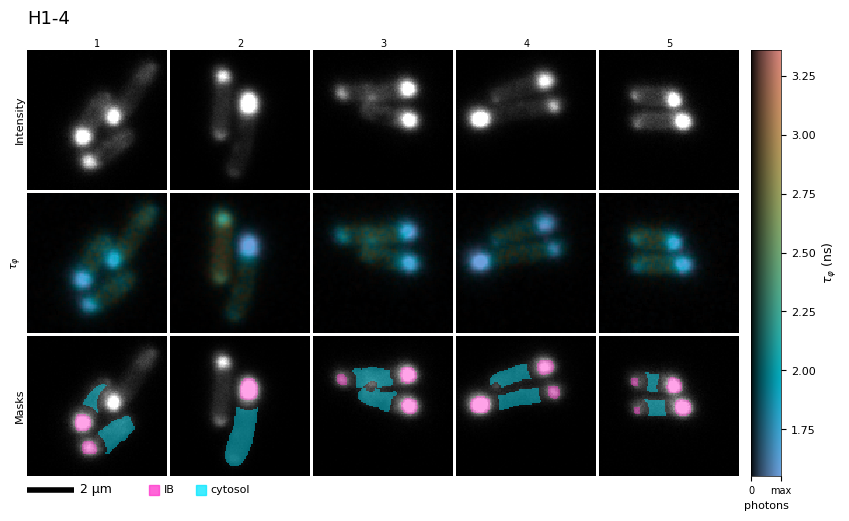

In [11]:
plot_construct_summary(edge_reference_sample['2025-07-30']);

## Image table

One row per image: geometry, calibration factor, which masks it has, its
column in the construct summary and its photon-weighted median lifetime.

In [12]:
def median_lifetime(entry):
    """Photon-weighted median tau_phi of the pixels with enough photons."""
    tau, weight = usable_pixels(entry)
    return float(weighted_percentile(tau, weight, [50])[0]) if tau.size else np.nan


table = pd.DataFrame([{
    'date':            entry['date'],
    'sample':          display_name(sample),
    'sample_folder':   sample,
    'ptu_file':        ptu_file,
    'photons':         int(entry['counts'].sum()),
    'lines':           entry['shape'][0],
    'pixels':          entry['shape'][1],
    'pixel_size_um':   entry['pixel_size_um'],
    'ib_mask':         'ib' in entry['masks'],
    'cell_mask':       'cell' in entry['masks'],
    'summary_column':  summary_column.get((sample, ptu_file)),
    'median_tau_phi_ns': median_lifetime(entry),
    'spatial_pooling': spatial_pooling,
    'tau_min_ns':      tau_min,
    'tau_max_ns':      tau_max,
    'factor':          total_factor[entry['date']],
} for (sample, ptu_file), entry in images.items()])

table['summary_column'] = table['summary_column'].astype('Int64')
table.to_csv(os.path.join(output_dir, "lifetime_maps.csv"), index=False)

inside = np.concatenate([usable_pixels(entry)[0] for entry in images.values()])
print(f"{100 * np.mean((inside >= tau_min) & (inside <= tau_max)):.1f}% of the usable pixels "
      f"of all images fall inside the lifetime scale.")
table.head()

84.6% of the usable pixels of all images fall inside the lifetime scale.


,date,sample,sample_folder,ptu_file,photons,lines,pixels,pixel_size_um,ib_mask,cell_mask,summary_column,median_tau_phi_ns,spatial_pooling,tau_min_ns,tau_max_ns,factor
0,2025-03-13,1259,1259,MultiHarp150_2025-03-13_15-19-12.ptu,550483,100,100,0.06,True,True,1,2.580539,3,1.552894,3.360651,0.967932-0.522888j
1,2025-03-13,1259,1259,MultiHarp150_2025-03-13_15-20-43.ptu,331713,100,100,0.06,True,True,2,2.222413,3,1.552894,3.360651,0.967932-0.522888j
2,2025-03-13,1259,1259,MultiHarp150_2025-03-13_15-21-42.ptu,384427,100,100,0.06,True,True,3,2.289236,3,1.552894,3.360651,0.967932-0.522888j
3,2025-03-13,1259,1259,MultiHarp150_2025-03-13_15-22-53.ptu,241274,100,100,0.06,True,True,4,2.483363,3,1.552894,3.360651,0.967932-0.522888j
4,2025-03-13,1259,1259,MultiHarp150_2025-03-13_15-23-43.ptu,254754,100,100,0.06,True,True,5,2.027355,3,1.552894,3.360651,0.967932-0.522888j
